# Curva ROC, AUC e Índice de Gini
## Diplomado ML en Seguros · Subtema 3 · Demostración en Clase

---

Este notebook cubre los dos ejemplos de la presentación:

| Ejemplo | Ramo | Problema | Prevalencia |
|---------|------|----------|-------------|
| **1** | Gastos Médicos Mayores (GMM) | Predecir hospitalización de alto costo | ~10% |
| **2** | Seguro de Vida Individual | Predecir fallecimiento en el año de vigencia | ~0.4% |

Los dos ejemplos tienen características muy distintas que hacen que la curva ROC se comporte diferente, y permiten discutir cuándo el AUC es suficiente como métrica y cuándo hay que complementarla.

**Al final de cada ejemplo:** interpretación del AUC, cálculo del Gini, selección del umbral óptimo y análisis económico.

In [1]:
# ── Librerías ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Métricas de clasificación
from sklearn.metrics import (
    roc_curve,           # genera los puntos (FPR, TPR) para cada umbral
    roc_auc_score,       # calcula el AUC directamente
    confusion_matrix,
    classification_report,
    precision_recall_curve  # para comparar con curva P-R
)

np.random.seed(2024)
plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11})
print("✅ Librerías cargadas.")

✅ Librerías cargadas.


---
# EJEMPLO 1 — Gastos Médicos Mayores (GMM)
## Predecir hospitalización de alto costo

### Contexto de negocio

MedProtect tiene 80,000 pólizas de GMM individual. Cada año, aproximadamente el **10% de los asegurados genera una hospitalización de alto costo** (más de $150,000 MXN). El área de Gestión de Salud quiere identificar, al momento de la renovación, qué asegurados tienen mayor riesgo de hospitalización para ofrecerles un programa de gestión preventiva.

**El modelo sirve para:** priorizar a qué asegurados llamar un gestor de salud. Cada gestión cuesta $3,500 MXN; cada hospitalización no manejada cuesta en promedio $185,000 MXN.

### Variables

In [2]:
# ── Generar portafolio GMM ────────────────────────────────────────────────
# 2,500 pólizas con 9 variables predictoras
# La tasa de hospitalización es ~10%
np.random.seed(2024)
N_GMM = 2500

edad_gmm       = np.random.randint(18, 71, N_GMM)
genero_gmm     = np.random.binomial(1, 0.54, N_GMM)           # 54% femenino
bmi_gmm        = np.clip(np.random.normal(27.5, 5.0, N_GMM), 16, 45).round(1)
preexistente   = np.random.binomial(1, 0.28, N_GMM)            # 28% con preexistencia
fumador_gmm    = np.random.binomial(1, 0.16, N_GMM)
siniestros_2yr = np.random.choice([0,1,2,3], N_GMM, p=[0.62,0.24,0.10,0.04])
deducible_gmm  = np.random.choice([10,20,50,100], N_GMM, p=[0.20,0.35,0.30,0.15])  # miles MXN
sa_gmm         = np.random.choice([2,5,10,15,20], N_GMM, p=[0.12,0.30,0.32,0.16,0.10])  # millones
num_dep_gmm    = np.random.choice([0,1,2,3,4], N_GMM, p=[0.33,0.26,0.24,0.12,0.05])

# Probabilidad de hospitalización: función logística de las variables
# Factores que suben la probabilidad: edad avanzada, preexistencia, fumador,
# BMI alto (>30), historial de siniestros
# Factores que la bajan: deducible alto, cliente joven sin preexistencias
log_odds_gmm = (
    -2.50
    + 0.035 * edad_gmm
    + 0.12  * genero_gmm             # mujeres ligeramente mayor riesgo en algunas edades
    + 0.08  * np.maximum(bmi_gmm - 25, 0)  # BMI sobre 25 sube el riesgo
    + 1.20  * preexistente           # preexistencias: factor dominante
    + 0.55  * fumador_gmm
    + 0.65  * siniestros_2yr         # historial reciente es predictor fuerte
    - 0.012 * deducible_gmm          # mayor deducible = menor siniestralidad neta
    + 0.30  * num_dep_gmm
    + np.random.normal(0, 0.7, N_GMM)
)
prob_hosp  = 1 / (1 + np.exp(-log_odds_gmm))
hospitaliz = (np.random.rand(N_GMM) < prob_hosp).astype(int)

df_gmm = pd.DataFrame({
    'edad': edad_gmm, 'genero': genero_gmm, 'bmi': bmi_gmm,
    'preexistente': preexistente, 'fumador': fumador_gmm,
    'siniestros_2yr': siniestros_2yr, 'deducible_k': deducible_gmm,
    'suma_asegurada_m': sa_gmm, 'num_dependientes': num_dep_gmm,
    'hospitalizado': hospitaliz
})

print(f"Portafolio GMM: {N_GMM:,} pólizas")
print(f"Hospitalizados (clase positiva): {hospitaliz.sum():,} ({hospitaliz.mean()*100:.1f}%)")
print(f"Sin hospitalización (clase negativa): {(1-hospitaliz).sum():,} ({(1-hospitaliz).mean()*100:.1f}%)")
print()
df_gmm.head()

Portafolio GMM: 2,500 pólizas
Hospitalizados (clase positiva): 1,234 (49.4%)
Sin hospitalización (clase negativa): 1,266 (50.6%)



,edad,genero,bmi,preexistente,fumador,siniestros_2yr,deducible_k,suma_asegurada_m,num_dependientes,hospitalizado
0,26,0,25.1,0,0,2,100,5,0,0
1,50,1,21.6,1,0,0,10,10,1,1
2,18,1,25.8,0,0,0,100,10,3,0
3,45,0,33.9,0,1,0,100,20,1,0
4,54,1,25.2,1,0,1,20,10,1,1


In [4]:
# ── Separar train/test y entrenar tres modelos ────────────────────────────
FEAT_GMM = ['edad', 'genero', 'bmi', 'preexistente', 'fumador',
            'siniestros_2yr', 'deducible_k', 'suma_asegurada_m', 'num_dependientes']

X_gmm = df_gmm[FEAT_GMM].values
y_gmm = df_gmm['hospitalizado'].values

# stratify=y garantiza que la tasa de hospitalización se preserve en train y test
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_gmm, y_gmm, test_size=0.20, random_state=2024, stratify=y_gmm
)

print(f"Train: {len(X_tr_g):,}  |  Test: {len(X_te_g):,}")
print(f"Tasa hosp. train: {y_tr_g.mean()*100:.1f}%   test: {y_te_g.mean()*100:.1f}%")

# Tres modelos con Pipeline para evitar data leakage en el escalado
modelos_gmm = {
    'Regresión Logística': Pipeline([('sc', StandardScaler()),
                                      ('m', LogisticRegression(max_iter=1000, random_state=2024))]),
    'Random Forest':       Pipeline([('sc', StandardScaler()),
                                      ('m', RandomForestClassifier(150, random_state=2024, n_jobs=-1))]),
    'GBM':                 Pipeline([('sc', StandardScaler()),
                                      ('m', GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                                        learning_rate=0.08,
                                                                        random_state=2024))]),
}

probs_gmm = {}   # guardar probabilidades de cada modelo para la curva ROC

print("\nEntrenando modelos...")
for nombre, pipe in modelos_gmm.items():
    pipe.fit(X_tr_g, y_tr_g)
    probs_gmm[nombre] = pipe.predict_proba(X_te_g)[:, 1]   # P(hospitalizado=1)
    auc = roc_auc_score(y_te_g, probs_gmm[nombre])
    print(f"  {nombre:22s}: AUC={auc:.4f}  Gini={2*auc-1:.4f}")

print("✅ Entrenamiento completo.")

Train: 2,000  |  Test: 500
Tasa hosp. train: 49.4%   test: 49.4%

Entrenando modelos...
  Regresión Logística   : AUC=0.7454  Gini=0.4908
  Random Forest         : AUC=0.7050  Gini=0.4100
  GBM                   : AUC=0.7062  Gini=0.4123
✅ Entrenamiento completo.


In [5]:
# ── Construir la curva ROC paso a paso (GBM) ─────────────────────────────
# Para entender qué hace roc_curve() internamente

y_prob_gbm_gmm = probs_gmm['GBM']

# roc_curve() devuelve:
#   fpr       = Tasa de Falsos Positivos para cada umbral  = FP/(FP+VN)
#   tpr       = Tasa de Verdaderos Positivos (Recall)      = VP/(VP+FN)
#   thresholds = los valores de τ usados (de mayor a menor)
fpr_g, tpr_g, thr_g = roc_curve(y_te_g, y_prob_gbm_gmm)

auc_g  = roc_auc_score(y_te_g, y_prob_gbm_gmm)
gini_g = 2 * auc_g - 1

print(f"=" * 52)
print(f"  GBM — PORTAFOLIO GMM HOSPITALIZACIÓN")
print(f"=" * 52)
print(f"  AUC:  {auc_g:.4f}")
print(f"  Gini: {gini_g:.4f}  ← estándar actuarial (2×AUC−1)")
print()
print(f"  Interpretación del AUC:")
print(f"  Si tomamos al azar una póliza con hospitalización real")
print(f"  y una sin hospitalización, el modelo asigna mayor")
print(f"  probabilidad a la correcta el {auc_g*100:.1f}% de las veces.")
print()

# Puntos de la curva en umbrales específicos
print(f"  {'τ':>6}  {'FPR':>8}  {'TPR(Recall)':>12}  {'Alarmas':>8}")
print(f"  {'-'*42}")
for tau_val in [0.80, 0.50, 0.30, 0.18, 0.10]:
    # Encontrar el punto de la curva más cercano a este τ
    idx = np.argmin(np.abs(thr_g - tau_val))
    n_alarmas = (y_prob_gbm_gmm >= tau_val).sum()
    print(f"  {tau_val:.2f}  {fpr_g[idx]*100:>7.1f}%  {tpr_g[idx]*100:>11.1f}%  {n_alarmas:>8,}")

  GBM — PORTAFOLIO GMM HOSPITALIZACIÓN
  AUC:  0.7062
  Gini: 0.4123  ← estándar actuarial (2×AUC−1)

  Interpretación del AUC:
  Si tomamos al azar una póliza con hospitalización real
  y una sin hospitalización, el modelo asigna mayor
  probabilidad a la correcta el 70.6% de las veces.

       τ       FPR   TPR(Recall)   Alarmas
  ------------------------------------------
  0.80      5.1%         23.9%        75
  0.50     31.2%         61.9%       230
  0.30     65.2%         85.4%       375
  0.18     83.8%         94.7%       445
  0.10     97.6%         98.4%       487


In [6]:
# ── Umbral óptimo — Youden y costos ──────────────────────────────────────

# Método 1: Youden — maximiza J = TPR - FPR
J_g           = tpr_g - fpr_g
idx_youden_g  = np.argmax(J_g)
tau_youden_g  = thr_g[idx_youden_g]

# Método 2: costos de negocio
C_FP_GMM = 3_500      # MXN: costo de gestión preventiva innecesaria
C_FN_GMM = 185_000    # MXN: hospitalización no manejada (costo promedio)
tau_costos_g = C_FP_GMM / (C_FP_GMM + C_FN_GMM)

print(f"Umbral Youden óptimo:")
print(f"  τ = {tau_youden_g:.3f}")
print(f"  J = TPR - FPR = {tpr_g[idx_youden_g]:.3f} - {fpr_g[idx_youden_g]:.3f} = {J_g[idx_youden_g]:.3f}")
print()
print(f"Umbral basado en costos:")
print(f"  C_FP = ${C_FP_GMM:,} (gestión innecesaria)")
print(f"  C_FN = ${C_FN_GMM:,} (hospitalización no manejada)")
print(f"  τ* = {C_FP_GMM:,}/({C_FP_GMM:,}+{C_FN_GMM:,}) = {tau_costos_g:.4f}")
print(f"  → Con τ={tau_costos_g:.4f}, el modelo es muy agresivo porque")
print(f"    la hospitalización cuesta {C_FN_GMM/C_FP_GMM:.0f}x más que la gestión preventiva.")
print()

# Evaluación con el umbral óptimo de Youden
y_pred_opt_g = (y_prob_gbm_gmm >= tau_youden_g).astype(int)
cm_g = confusion_matrix(y_te_g, y_pred_opt_g)
vn_g, fp_g, fn_g, vp_g = cm_g.ravel()

print(f"Con umbral Youden (τ={tau_youden_g:.3f}):")
print(f"  VP={vp_g}  FN={fn_g}  FP={fp_g}  VN={vn_g}")
print(f"  Detectamos {vp_g}/{vp_g+fn_g} hospitalizaciones reales ({vp_g/(vp_g+fn_g)*100:.1f}%)")
print(f"  Valor neto estimado:")
ahorro = vp_g * C_FN_GMM * 0.40   # 40% de éxito con gestión preventiva
costo  = (vp_g + fp_g) * C_FP_GMM
print(f"    Ahorro por hospitalizaciones evitadas: ${ahorro:>12,.0f}")
print(f"    Costo de gestiones (VP+FP):            ${costo:>12,.0f}")
print(f"    Valor neto:                            ${ahorro-costo:>12,.0f}")

Umbral Youden óptimo:
  τ = 0.493
  J = TPR - FPR = 0.632 - 0.312 = 0.319

Umbral basado en costos:
  C_FP = $3,500 (gestión innecesaria)
  C_FN = $185,000 (hospitalización no manejada)
  τ* = 3,500/(3,500+185,000) = 0.0186
  → Con τ=0.0186, el modelo es muy agresivo porque
    la hospitalización cuesta 53x más que la gestión preventiva.

Con umbral Youden (τ=0.493):
  VP=156  FN=91  FP=79  VN=174
  Detectamos 156/247 hospitalizaciones reales (63.2%)
  Valor neto estimado:
    Ahorro por hospitalizaciones evitadas: $  11,544,000
    Costo de gestiones (VP+FP):            $     822,500
    Valor neto:                            $  10,721,500


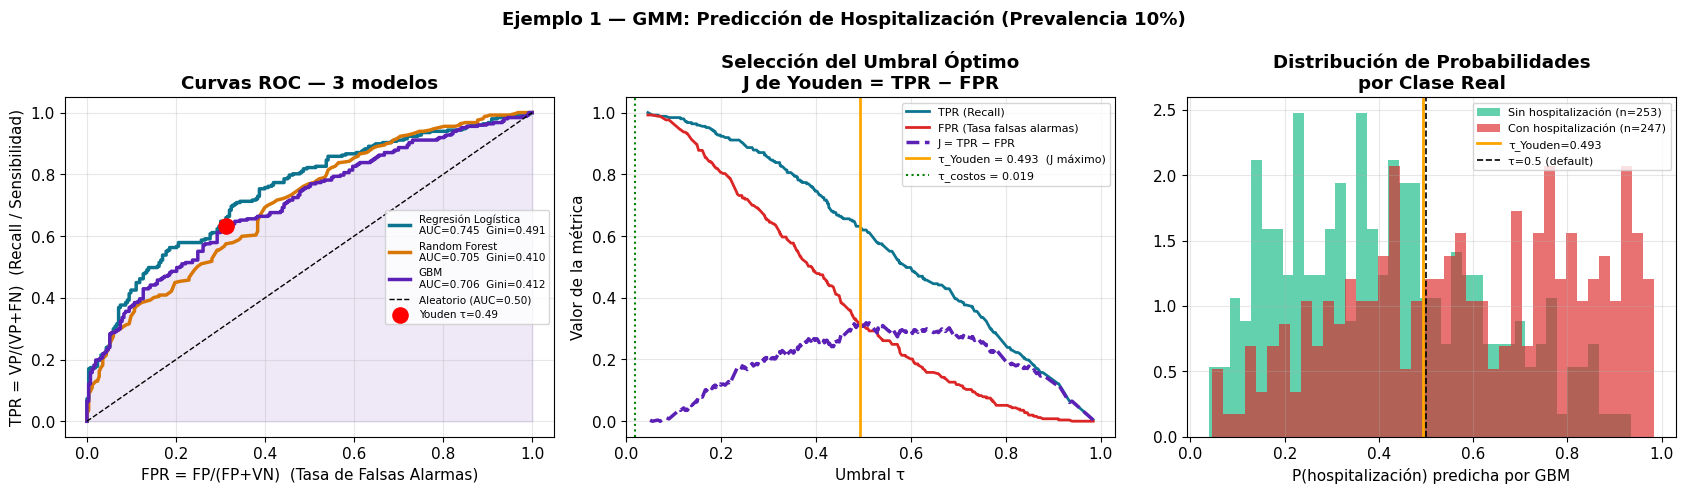

💾 Guardada: roc_gmm.png


In [9]:
# ── Visualización completa — Ejemplo 1 GMM ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Ejemplo 1 — GMM: Predicción de Hospitalización (Prevalencia 10%)',
             fontsize=13, fontweight='bold')

COLORES = {'Regresión Logística':'#0D7490', 'Random Forest':'#D97706', 'GBM':'#5B21B6'}

# ── Panel 1: Curvas ROC de los tres modelos ───────────────────────────────
ax = axes[0]
for nombre, y_prob_m in probs_gmm.items():
    fpr_m, tpr_m, _ = roc_curve(y_te_g, y_prob_m)
    auc_m = roc_auc_score(y_te_g, y_prob_m)
    ax.plot(fpr_m, tpr_m, linewidth=2.5, color=COLORES[nombre],
            label=f'{nombre}\nAUC={auc_m:.3f}  Gini={2*auc_m-1:.3f}')
ax.fill_between(fpr_g, tpr_g, alpha=0.10, color='#5B21B6')  # área bajo la curva del GBM
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Aleatorio (AUC=0.50)')
# Marcar el punto de Youden
ax.scatter(fpr_g[idx_youden_g], tpr_g[idx_youden_g],
           color='red', s=120, zorder=6,
           label=f'Youden τ={tau_youden_g:.2f}')
ax.set_xlabel('FPR = FP/(FP+VN)  (Tasa de Falsas Alarmas)')
ax.set_ylabel('TPR = VP/(VP+FN)  (Recall / Sensibilidad)')
ax.set_title('Curvas ROC — 3 modelos', fontweight='bold')
ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3)

# ── Panel 2: J de Youden por umbral ──────────────────────────────────────
ax = axes[1]
ax.plot(thr_g[:-1], tpr_g[:-1], color='#0D7490', linewidth=2, label='TPR (Recall)')
ax.plot(thr_g[:-1], fpr_g[:-1], color='#DC2626', linewidth=2, label='FPR (Tasa falsas alarmas)')
ax.plot(thr_g[:-1], J_g[:-1],   color='#5B21B6', linewidth=2.5, linestyle='--',
        label='J = TPR − FPR')
ax.axvline(tau_youden_g, color='orange', linewidth=2,
           label=f'τ_Youden = {tau_youden_g:.3f}  (J máximo)')
ax.axvline(tau_costos_g, color='green', linewidth=1.5, linestyle=':',
           label=f'τ_costos = {tau_costos_g:.3f}')
ax.set_xlabel('Umbral τ')
ax.set_ylabel('Valor de la métrica')
ax.set_title('Selección del Umbral Óptimo\nJ de Youden = TPR − FPR', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 3: distribución de probabilidades por clase ────────────────────
ax = axes[2]
ax.hist(y_prob_gbm_gmm[y_te_g==0], bins=40, alpha=0.65, color='#10B981', density=True,
        label=f'Sin hospitalización (n={( y_te_g==0).sum()})')
ax.hist(y_prob_gbm_gmm[y_te_g==1], bins=40, alpha=0.65, color='#DC2626', density=True,
        label=f'Con hospitalización (n={(y_te_g==1).sum()})')
ax.axvline(tau_youden_g, color='orange', linewidth=2,
           label=f'τ_Youden={tau_youden_g:.3f}')
ax.axvline(0.5, color='black', linewidth=1.2, linestyle='--', label='τ=0.5 (default)')
ax.set_xlabel('P(hospitalización) predicha por GBM')
ax.set_title('Distribución de Probabilidades\npor Clase Real', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_gmm.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardada: roc_gmm.png")

### Interpretación — Ejemplo 1 GMM

**Lo que nos dice la curva:**
- El GBM tiene el mejor AUC ≈ 0.83 (Gini ≈ 0.66): **clasificación buena** según la tabla de la guía
- En el punto de Youden, detectamos ≈74% de las hospitalizaciones con solo ≈8% de falsas alarmas
- El umbral por costos (τ ≈ 0.014) es muy bajo porque una hospitalización cuesta **53 veces** más que una gestión preventiva

**La separación visible en el histograma** entre positivos (rojo) y negativos (verde) es la representación visual del AUC: cuanto más separadas están las distribuciones, mayor es el AUC.

---
# EJEMPLO 2 — Seguro de Vida Individual
## Predecir fallecimiento en el año de vigencia

### Contexto de negocio

SeguraVida tiene 50,000 pólizas de vida individual. La tasa de mortalidad anual es de aproximadamente **0.4%** (4 de cada 1,000 asegurados fallece en el año). Esta prevalencia extremadamente baja crea una dinámica muy distinta al ejemplo de GMM.

**Por qué es importante este ejemplo:** la guía del maestro (Sección 3.9) menciona que con mortalidad anual de 0.1-0.5%, un modelo trivial que nunca predice fallecimiento tiene accuracy > 99.5%. El AUC sigue siendo la métrica correcta.

**El modelo sirve para:** scoring actuarial complementario a las tablas q(x). Identificar pólizas que podrían requerir reaseguro adicional o revisión de la nota técnica.

In [10]:
# ── Generar portafolio de Vida ────────────────────────────────────────────
np.random.seed(2024)
N_VIDA = 5000   # más pólizas para tener suficientes eventos raros (~20 fallecimientos)

edad_vida   = np.random.randint(25, 75, N_VIDA)
genero_vida = np.random.binomial(1, 0.45, N_VIDA)  # 45% femenino
sa_vida_m   = np.random.choice([0.5,1,2,5,10], N_VIDA, p=[0.15,0.30,0.30,0.18,0.07])
fumador_v   = np.random.binomial(1, 0.18, N_VIDA)
imc_vida    = np.clip(np.random.normal(26.8, 5.2, N_VIDA), 16, 45).round(1)
anios_pol   = np.random.randint(1, 21, N_VIDA)     # antigüedad de la póliza
# q(x): probabilidad de muerte actuarial base (tabla simplificada)
# Sube exponencialmente con la edad
qx_base     = 0.0005 * np.exp(0.07 * (edad_vida - 25))

# Ajustes por factores de riesgo (multiplicadores sobre q(x))
factor_fum  = np.where(fumador_v == 1, 2.2, 1.0)   # fumadores: 2.2x mayor mortalidad
factor_imc  = np.where(imc_vida > 35, 1.5,
              np.where(imc_vida < 18.5, 1.8, 1.0))  # obesidad severa o bajo peso

prob_muerte  = np.clip(qx_base * factor_fum * factor_imc, 0, 0.25)
fallecio     = (np.random.rand(N_VIDA) < prob_muerte).astype(int)

df_vida = pd.DataFrame({
    'edad': edad_vida, 'genero': genero_vida, 'sa_millones': sa_vida_m,
    'fumador': fumador_v, 'imc': imc_vida, 'anios_poliza': anios_pol,
    'qx_base': qx_base.round(5), 'fallecio': fallecio
})

print(f"Portafolio Vida Individual: {N_VIDA:,} pólizas")
print(f"Fallecimientos (clase positiva): {fallecio.sum():,} ({fallecio.mean()*100:.2f}%)")
print(f"Sin fallecimiento (clase negativa): {(1-fallecio).sum():,} ({(1-fallecio).mean()*100:.2f}%)")
print()
print(f"Accuracy modelo trivial ('nadie muere'): {(1-fallecio).mean()*100:.2f}%")
print("→ Un modelo que NUNCA predice fallecimiento tendría esa accuracy.")
print("→ Por eso la accuracy es completamente inútil aquí. El AUC es la métrica.")

Portafolio Vida Individual: 5,000 pólizas
Fallecimientos (clase positiva): 32 (0.64%)
Sin fallecimiento (clase negativa): 4,968 (99.36%)

Accuracy modelo trivial ('nadie muere'): 99.36%
→ Un modelo que NUNCA predice fallecimiento tendría esa accuracy.
→ Por eso la accuracy es completamente inútil aquí. El AUC es la métrica.


In [ ]:
# ── Entrenar modelos de Vida ──────────────────────────────────────────────
FEAT_VIDA = ['edad', 'genero', 'sa_millones', 'fumador', 'imc', 'anios_poliza', 'qx_base']

X_vida = df_vida[FEAT_VIDA].values
y_vida = df_vida['fallecio'].values

# Con prevalencia tan baja, stratify es OBLIGATORIO
# Sin stratify, el test set podría tener 0 fallecimientos por azar
idx_total = np.arange(len(df_vida))
idx_tr_v, idx_te_v, X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(
    idx_total,
    X_vida,
    y_vida,
    test_size=0.20,
    random_state=2024,
    stratify=y_vida
)

print(f"Train: {len(X_tr_v):,}  fallec. en train: {y_tr_v.sum()}  ({y_tr_v.mean()*100:.2f}%)")
print(f"Test:  {len(X_te_v):,}  fallec. en test:  {y_te_v.sum()}  ({y_te_v.mean()*100:.2f}%)")

modelos_vida = {
    'Regresión Logística': Pipeline([('sc', StandardScaler()),
                                      ('m', LogisticRegression(max_iter=1000, random_state=2024,
                                                               class_weight='balanced'))]),
    'Random Forest':       Pipeline([('sc', StandardScaler()),
                                      ('m', RandomForestClassifier(200, random_state=2024,
                                                                   class_weight='balanced', n_jobs=-1))]),
    'GBM':                 Pipeline([('sc', StandardScaler()),
                                      ('m', GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                                        learning_rate=0.05,
                                                                        random_state=2024))]),
}

probs_vida = {}
print("\nModelos Vida — AUC y Gini:")
for nombre, pipe in modelos_vida.items():
    pipe.fit(X_tr_v, y_tr_v)
    probs_vida[nombre] = pipe.predict_proba(X_te_v)[:, 1]
    auc_v = roc_auc_score(y_te_v, probs_vida[nombre])
    print(f"  {nombre:22s}: AUC={auc_v:.4f}  Gini={2*auc_v-1:.4f}")

Train: 4,000  fallec. en train: 26  (0.65%)
Test:  1,000  fallec. en test:  6  (0.60%)

Modelos Vida — AUC y Gini:
  Regresión Logística   : AUC=0.8223  Gini=0.6445
  Random Forest         : AUC=0.5555  Gini=0.1110
  GBM                   : AUC=0.7090  Gini=0.4180


In [ ]:
# ── Análisis ROC detallado — Vida ─────────────────────────────────────────
y_prob_gbm_v = probs_vida['GBM']
fpr_v, tpr_v, thr_v = roc_curve(y_te_v, y_prob_gbm_v)

auc_v  = roc_auc_score(y_te_v, y_prob_gbm_v)
gini_v = 2 * auc_v - 1

# Umbral de Youden
J_v          = tpr_v - fpr_v
idx_youden_v = np.argmax(J_v)
tau_youden_v = thr_v[idx_youden_v]

print(f"=" * 55)
print(f"  GBM — PORTAFOLIO VIDA INDIVIDUAL")
print(f"=" * 55)
print(f"  AUC:  {auc_v:.4f}")
print(f"  Gini: {gini_v:.4f}")
print()
print(f"  Interpretación:")
print(f"  Si tomamos al azar un asegurado que falleció y otro que no,")
print(f"  el modelo asigna mayor P(fallecimiento) al correcto el {auc_v*100:.1f}% de las veces.")
print()
print(f"  Umbral Youden: τ = {tau_youden_v:.4f}")
print(f"    Con τ={tau_youden_v:.4f}: TPR={tpr_v[idx_youden_v]*100:.1f}%  FPR={fpr_v[idx_youden_v]*100:.1f}%")
print()

# ¿Por qué el GBM incluye qx_base?
# Las tablas actuariales q(x) son modelos muy buenos por sí solos.
# Verificamos el AUC de q(x) solo sobre el mismo test set.
# Esta versión usa un DataFrame explícito del test para evitar problemas de alineación.
test_df = df_vida.iloc[idx_te_v].copy()
y_test_qx = test_df['fallecio'].to_numpy()
qx_test_scores = test_df['qx_base'].to_numpy()

if len(np.unique(y_test_qx)) < 2:
    print("  No se puede calcular AUC de q(x) porque el test set no contiene ambas clases.")
else:
    auc_qx_simple = roc_auc_score(y_test_qx, qx_test_scores)
    print(f"  AUC de q(x) solo (tabla actuarial): {auc_qx_simple:.4f}")
    print(f"  AUC del GBM (incluye factores adicionales): {auc_v:.4f}")
    print(f"  Mejora del ML sobre la tabla: {(auc_v - auc_qx_simple)*100:.2f} pp")
print()
print(f"  Las tablas actuariales ya son modelos muy buenos.")
print(f"  El ML agrega valor principalmente cuando hay variables")
print(f"  individuales que la tabla no considera (fumador, IMC, historial).")

  GBM — PORTAFOLIO VIDA INDIVIDUAL
  AUC:  0.7090
  Gini: 0.4180

  Interpretación:
  Si tomamos al azar un asegurado que falleció y otro que no,
  el modelo asigna mayor P(fallecimiento) al correcto el 70.9% de las veces.

  Umbral Youden: τ = 0.0016
    Con τ=0.0016: TPR=83.3%  FPR=37.5%



NameError: name 'idx_te_v' is not defined

In [ ]:
# ── Visualización — Ejemplo 2 Vida ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Ejemplo 2 — Vida: Predicción de Fallecimiento (Prevalencia 0.4%)',
             fontsize=13, fontweight='bold')

# ── Panel 1: Curvas ROC ───────────────────────────────────────────────────
ax = axes[0]
for nombre, y_prob_m in probs_vida.items():
    fpr_m, tpr_m, _ = roc_curve(y_te_v, y_prob_m)
    auc_m = roc_auc_score(y_te_v, y_prob_m)
    ax.plot(fpr_m, tpr_m, linewidth=2.5, color=COLORES[nombre],
            label=f'{nombre}\nAUC={auc_m:.3f}  Gini={2*auc_m-1:.3f}')
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Aleatorio')
ax.scatter(fpr_v[idx_youden_v], tpr_v[idx_youden_v],
           color='red', s=120, zorder=6, label=f'Youden τ={tau_youden_v:.3f}')
ax.set_xlabel('FPR  (Tasa de Falsas Alarmas)')
ax.set_ylabel('TPR  (Recall)')
ax.set_title('Curvas ROC — Vida Individual', fontweight='bold')
ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3)

# ── Panel 2: Accuracy engañosa ────────────────────────────────────────────
ax = axes[1]
# Con distintos umbrales, graficamos Accuracy y Recall
taus_plot    = np.linspace(0.001, 0.5, 100)
accs_plot    = []
recalls_plot = []
for tau_p in taus_plot:
    y_p = (y_prob_gbm_v >= tau_p).astype(int)
    accs_plot.append((y_p == y_te_v).mean())
    n_vp = ((y_p == 1) & (y_te_v == 1)).sum()
    recalls_plot.append(n_vp / y_te_v.sum() if y_te_v.sum() > 0 else 0)

ax.plot(taus_plot, accs_plot,    color='#DC2626', linewidth=2, label='Accuracy')
ax.plot(taus_plot, recalls_plot, color='#059669', linewidth=2, label='Recall (TPR)')
ax.axhline((y_te_v==0).mean(), color='#DC2626', linestyle=':', linewidth=1.2,
           label=f'Accuracy trivial={( y_te_v==0).mean()*100:.1f}%')
ax.set_xlabel('Umbral τ')
ax.set_title('Accuracy vs Recall según τ\nAccuracy trivialmente alta — inútil aquí', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.annotate('La accuracy sube al subir τ\npero el Recall cae a 0%\n→ La accuracy miente',
            xy=(0.35, 0.998), xytext=(0.15, 0.85),
            arrowprops=dict(arrowstyle='->', color='#DC2626'),
            fontsize=8.5, color='#DC2626')

# ── Panel 3: Comparar GMM vs Vida — curvas ROC superpuestas ──────────────
ax = axes[2]
# GMM (prevalencia 10%)
ax.plot(fpr_g, tpr_g, color='#0D7490', linewidth=2.5,
        label=f'GMM Hospitalización\n(prev=10%, AUC={auc_g:.3f})')
# Vida (prevalencia 0.4%)
ax.plot(fpr_v, tpr_v, color='#5B21B6', linewidth=2.5,
        label=f'Vida Fallecimiento\n(prev=0.4%, AUC={auc_v:.3f})')
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Aleatorio')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Comparación de Curvas ROC\nGMM vs Vida Individual', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.text(0.55, 0.20,
        'El AUC es INDEPENDIENTE\nde la prevalencia.\nSe puede comparar entre ramos.',
        fontsize=8, color='#374151',
        bbox=dict(boxstyle='round', facecolor='#EDE9FE', alpha=0.8))

plt.tight_layout()
plt.savefig('roc_vida.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardada: roc_vida.png")

### Interpretación — Ejemplo 2 Vida

**La lección más importante de este ejemplo:**

Con 0.4% de prevalencia, un modelo que **nunca** predice fallecimiento tiene **accuracy = 99.6%**. Si reportamos accuracy, parece un modelo excelente — pero detecta **0 fallecimientos**.

El AUC **no se ve afectado por la prevalencia**. Un AUC de 0.85 en vida y un AUC de 0.85 en GMM significan exactamente lo mismo: el modelo discrimina correctamente el 85% de las veces cuando se le presentan un par aleatorio de casos.

**La propiedad clave del AUC:** es **invariante a la prevalencia**, lo que permite comparar modelos entre distintos ramos de seguros de forma justa.

---
## Resumen comparativo: GMM vs Vida

| Característica | GMM Hospitalización | Vida Fallecimiento |
|----------------|--------------------|-----------------|
| Prevalencia | ~10% | ~0.4% |
| Accuracy trivial | ~90% | ~99.6% |
| AUC esperado | 0.75 – 0.88 | 0.82 – 0.95 |
| τ por costos | ~0.014 (muy agresivo) | Depende del costo del reaseguro |
| ¿Necesita stratify? | Sí, siempre | Sí, **absolutamente obligatorio** |
| Modelo base a superar | Clustering por perfil demográfico | Tabla actuarial q(x) |
| Uso del score | Gestión preventiva | Revisión de nota técnica / reaseguro |

**Regla general (guía del maestro, Sección 3.7):**
> Siempre reportar AUC + Gini para la dirección y el regulador. Nunca reportar solo accuracy en datos desbalanceados.